<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Deep Learning and Reinforcement Learning**

## Module 1 - Introduction to Neural Networks
### LAB: Pendahuluan Jaringan Saraf Tiruan (Neural Networks)

## **Latihan: Neuron sebagai Gerbang Logika**
Dalam latihan ini, kita akan bereksperimen dengan komputasi neuron. Kita akan menunjukkan bagaimana merepresentasikan fungsi logika dasar seperti **AND**, **OR**, dan **XOR** menggunakan neuron tunggal (atau struktur yang lebih rumit). Terakhir, kita akan mempelajari bagaimana merepresentasikan jaringan saraf sebagai rantai komputasi matriks.


In [1]:
import warnings
warnings.simplefilter('ignore')
import numpy as np
import matplotlib.pyplot as plt

### **Fungsi Sigmoid:**

$$
\sigma = \frac{1}{1 + e^{-x}}
$$

Nilai $\sigma$ berkisar antara (0, 1). 
* Ketika input $x$ bernilai negatif, $\sigma$ mendekati 0. 
* Ketika $x$ positif, $\sigma$ mendekati 1. 
* Pada $x=0$, nilai $\sigma=0,5$.


In [2]:
## Mendefinisikan fungsi sigmoid
def sigmoid(x):
    """Fungsi Sigmoid"""
    return 1.0 / (1.0 + np.exp(-x))

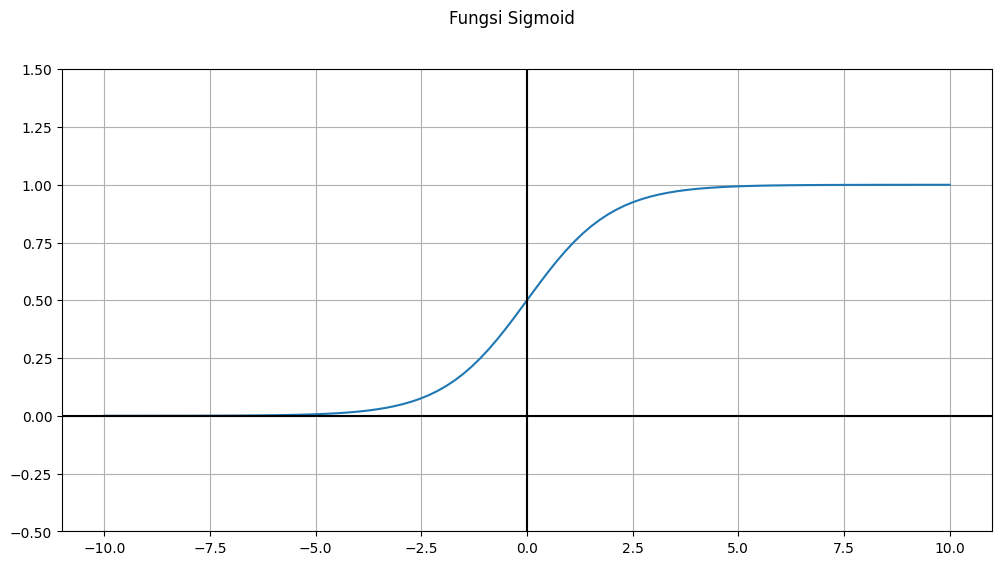

In [3]:
# Plot fungsi sigmoid
vals = np.linspace(-10, 10, num=100, dtype=np.float32)
activation = sigmoid(vals)
fig = plt.figure(figsize=(12,6))
fig.suptitle('Fungsi Sigmoid')
plt.plot(vals, activation)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.ylim([-0.5, 1.5])
plt.show()

### **Menganggap Neuron sebagai Gerbang Logika Boolean**

Gerbang logika menerima dua input boolean (benar/salah atau 1/0), dan mengembalikan 0 atau 1 tergantung pada aturannya. Tabel kebenaran (*truth table*) menunjukkan output untuk setiap kombinasi input: (0, 0), (0, 1), (1, 0), dan (1, 1). Sebagai contoh, mari kita lihat tabel kebenaran untuk gerbang "OR":

### **Gerbang OR**

<table>
<tr><th colspan="3">Tabel Kebenaran Gerbang OR</th></tr>
<tr><th colspan="2">Input</th><th>Output</th></tr>
<tr><td>0</td><td>0</td><td>0</td></tr>
<tr><td>0</td><td>1</td><td>1</td></tr>
<tr><td>1</td><td>0</td><td>1</td></tr>
<tr><td>1</td><td>1</td><td>1</td></tr>
</table>

Neuron yang menggunakan fungsi aktivasi sigmoid menghasilkan nilai antara (0, 1). Ini secara alami mengarahkan kita untuk memikirkan nilai boolean. Bayangkan sebuah neuron yang menerima dua input, $x_1$ dan $x_2$, serta sebuah bias:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/logic01.png)

Dengan membatasi input $x_1$ dan $x_2$ pada $\left\{0, 1\right\}$, kita dapat mensimulasikan efek gerbang logika. Tujuannya adalah mencari bobot (*weights*) sehingga neuron mengembalikan output mendekati 0 atau 1 sesuai aturan logika.

Berapa nilai bobot yang kita butuhkan untuk gerbang OR? Perhatikan bahwa $\sigma(z)$ mendekati 0 saat $z$ sangat negatif (sekitar -10 atau kurang), dan mendekati 1 saat $z$ sangat positif (sekitar +10 atau lebih).

$$
z = w_1 x_1 + w_2 x_2 + b
$$

Mari kita analisis:

*   Saat $x_1$ dan $x_2$ keduanya 0, nilai $z$ hanya dipengaruhi oleh bias $b$. Karena kita ingin hasilnya mendekati 0, maka **$b$ harus negatif** (misal -10).
*   Jika salah satu $x_1$ atau $x_2$ bernilai 1, kita ingin outputnya mendekati 1. Artinya bobot $w_1$ atau $w_2$ harus cukup besar untuk mengimbangi $b$ sehingga $z$ menjadi positif besar (misal +10).
*   Jika kita beri $b = -10$, maka $w_1$ dan $w_2$ setidaknya harus bernilai **+20**.

Mari kita coba $w_1=20$, $w_2=20$, dan $b=-10$!

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/logic02.png)


In [4]:
def logic_gate(w1, w2, b):
    # Fungsi pembantu untuk membuat gerbang logika
    # Masukkan nilai weight_1, weight_2, dan bias
    return lambda x1, x2: sigmoid(w1 * x1 + w2 * x2 + b)

def test(gate):
    # Fungsi pembantu untuk menguji gerbang logika
    for a, b in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        print(f"{a}, {b}: {np.round(gate(a, b))}")

In [5]:
or_gate = logic_gate(20, 20, -10)
print("Hasil Gerbang OR:")
test(or_gate)

Hasil Gerbang OR:
0, 0: 0.0
0, 1: 1.0
1, 0: 1.0
1, 1: 1.0


Sesuai! Bagus! Sekarang giliran Anda mencari nilai bobot yang tepat untuk setiap gerbang logika berikutnya. Cobalah berpikir secara logis daripada sekadar menebak-nebak.

### **Gerbang AND**

<table>
<tr><th colspan="3">Tabel Kebenaran Gerbang AND</th></tr>
<tr><th colspan="2">Input</th><th>Output</th></tr>
<tr><td>0</td><td>0</td><td>0</td></tr>
<tr><td>0</td><td>1</td><td>0</td></tr>
<tr><td>1</td><td>0</td><td>0</td></tr>
<tr><td>1</td><td>1</td><td>1</td></tr>
</table>


## **Latihan 1**
Tentukan nilai bobot dan bias agar fungsi di bawah ini bekerja sebagai gerbang **AND**.


In [6]:
# TUGAS: Isi parameter w1, w2, dan b agar tabel kebenaran sesuai
w1 = 15
w2 = 15
b = -25
and_gate = logic_gate(w1, w2, b)
print("Hasil Gerbang AND:")
test(and_gate)

Hasil Gerbang AND:
0, 0: 0.0
0, 1: 0.0
1, 0: 0.0
1, 1: 1.0


## **Latihan 2**
Lakukan hal yang sama untuk gerbang **NOR** dan **NAND**.


### **Gerbang NOR (Not Or)**

<table>
<tr><th colspan="3">Tabel Kebenaran Gerbang NOR</th></tr>
<tr><th colspan="2">Input</th><th>Output</th></tr>
<tr><td>0</td><td>0</td><td>1</td></tr>
<tr><td>0</td><td>1</td><td>0</td></tr>
<tr><td>1</td><td>0</td><td>0</td></tr>
<tr><td>1</td><td>1</td><td>0</td></tr>
</table>


In [7]:
# TUGAS: Isi parameter w1, w2, dan b agar tabel kebenaran sesuai
w1 = -20
w2 = -20
b = 10
nor_gate = logic_gate(w1, w2, b)
print("Hasil Gerbang NOR:")
test(nor_gate)

Hasil Gerbang NOR:
0, 0: 1.0
0, 1: 0.0
1, 0: 0.0
1, 1: 0.0


### **Gerbang NAND (Not And)**

<table>
<tr><th colspan="3">Tabel Kebenaran Gerbang NAND</th></tr>
<tr><th colspan="2">Input</th><th>Output</th></tr>
<tr><td>0</td><td>0</td><td>1</td></tr>
<tr><td>0</td><td>1</td><td>1</td></tr>
<tr><td>1</td><td>0</td><td>1</td></tr>
<tr><td>1</td><td>1</td><td>0</td></tr>
</table>


In [8]:
# TUGAS: Isi parameter w1, w2, dan b agar tabel kebenaran sesuai
w1 = -15
w2 = -15
b = 25
nand_gate = logic_gate(w1, w2, b)
print("Hasil Gerbang NAND:")
test(nand_gate)

Hasil Gerbang NAND:
0, 0: 1.0
0, 1: 1.0
1, 0: 1.0
1, 1: 0.0


## **Batasan Neuron Tunggal**

Gerbang **XOR** (Exclusive Or) adalah dasar dari banyak komputasi. XOR digunakan dalam sirkuit penambah (*half-adders*). Berikut tabel kebenarannya:

### **Gerbang XOR (Exclusive Or)**

<table>
<tr><th colspan="3">Tabel Kebenaran Gerbang XOR</th></tr>
<tr><th colspan="2">Input</th><th>Output</th></tr>
<tr><td>0</td><td>0</td><td>0</td></tr>
<tr><td>0</td><td>1</td><td>1</td></tr>
<tr><td>1</td><td>0</td><td>1</td></tr>
<tr><td>1</td><td>1</td><td>0</td></tr>
</table>

Dapatkah kita membuat satu neuron tunggal untuk gerbang XOR?

Ternyata **tidak bisa**, karena neuron tunggal tidak dapat memisahkan data yang tidak linear. Namun, kita bisa menggabungkan beberapa neuron:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/logic03.png)

Di sini, input masuk ke dua gerbang terpisah: neuron atas adalah gerbang **OR**, dan bawah adalah gerbang **NAND**. Output keduanya kemudian diteruskan ke neuron lain yaitu gerbang **AND**. Kombinasi ini akan menghasilkan logika **XOR**.


In [9]:
# Memastikan kita sudah mendefinisikan or_gate, nand_gate, dan and_gate sebelumnya
def xor_gate(a, b):
    c = or_gate(a, b)
    d = nand_gate(a, b)
    return and_gate(c, d)

print("Hasil Gerbang XOR:")
test(xor_gate)

Hasil Gerbang XOR:
0, 0: 0.0
0, 1: 1.0
1, 0: 1.0
1, 1: 0.0


## **Jaringan Feedforward sebagai Komputasi Matriks**

Komputasi *feed-forward* dalam jaringan saraf dapat dianggap sebagai serangkaian perkalian matriks dan fungsi aktivasi. Mari kita lihat implementasi nyatanya.

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/FF_NN.png)


## **Latihan 3**
Disediakan data berikut:

*   Tiga matriks bobot `W_1`, `W_2`, dan `W_3` yang merepresentasikan bobot tiap lapisan.
*   Vektor `x_in` (1 input) dan matriks `x_mat_in` (7 input).
*   Dua fungsi `soft_max_vec` dan `soft_max_mat` untuk aktivasi akhir.

Tujuan latihan:
1. Hitung input dan output tiap lapisan untuk `x_in` (gunakan sigmoid untuk lapisan tengah dan softmax untuk output akhir).
2. Buat fungsi untuk menghitung seluruh jaringan saraf untuk satu input.
3. Buat fungsi untuk menghitung seluruh jaringan saraf untuk matriks input.


In [10]:
W_1 = np.array([[2,-1,1,4],[-1,2,-3,1],[3,-2,-1,5]])
W_2 = np.array([[3,1,-2,1],[-2,4,1,-4],[-1,-3,2,-5],[3,1,1,1]])
W_3 = np.array([[-1,3,-2],[1,-1,-3],[3,-2,2],[1,2,1]])
x_in = np.array([.5,.8,.2])
x_mat_in = np.array([[.5,.8,.2],[.1,.9,.6],[.2,.2,.3],
                     [.6,.1,.9],[.5,.5,.4],[.9,.1,.9],[.1,.8,.7]])

def soft_max_vec(vec):
    return np.exp(vec)/(np.sum(np.exp(vec)))

def soft_max_mat(mat):
    return np.exp(mat)/(np.sum(np.exp(mat),axis=1).reshape(-1,1))

print('Matriks W_1:')
print(W_1)
print('-'*30)
print('Input vektor x_in:')
print(x_in)

Matriks W_1:
[[ 2 -1  1  4]
 [-1  2 -3  1]
 [ 3 -2 -1  5]]
------------------------------
Input vektor x_in:
[0.5 0.8 0.2]


In [11]:
# Menghitung lapisan demi lapisan secara manual
z_2 = np.dot(x_in, W_1)
a_2 = sigmoid(z_2)

z_3 = np.dot(a_2, W_2)
a_3 = sigmoid(z_3)

z_4 = np.dot(a_3, W_3)
y_out = soft_max_vec(z_4)

print(f"Output akhir (y_out): {y_out}")

Output akhir (y_out): [0.72780576 0.26927918 0.00291506]


In [12]:
## Fungsi satu baris untuk komputasi seluruh jaringan
def nn_comp_vec(x):
    return soft_max_vec(sigmoid(sigmoid(np.dot(x, W_1)).dot(W_2)).dot(W_3))

def nn_comp_mat(x):
    return soft_max_mat(sigmoid(sigmoid(np.dot(x, W_1)).dot(W_2)).dot(W_3))

print(f"Hasil komputasi vektor: {nn_comp_vec(x_in)}")

Hasil komputasi vektor: [0.72780576 0.26927918 0.00291506]


## **Contoh: Pengenalan Digit dengan Multi-layer Perceptron**

Dalam bagian ini, kita akan menggunakan `MLPClassifier` dari scikit-learn untuk mengenali gambar angka tulisan tangan dari dataset [Kaggle](https://www.kaggle.com/code/cezaryszulc/sklearn-simple-neural-network/notebook).

MLP menggunakan teknik pembelajaran **backpropagation**. Dengan banyak lapisan dan aktivasi non-linear, model ini mampu mengenali pola yang sangat rumit.


In [14]:
import pandas as pd
# dataset sudah diunduh sebelumnya
digits = pd.read_csv("digits.csv")

labels = digits['label']
digits = np.array(digits.drop('label', axis=1)).astype('float')
print(f"Data: {digits.shape}, Label: {labels.shape}")

Data: (42000, 784), Label: (42000,)


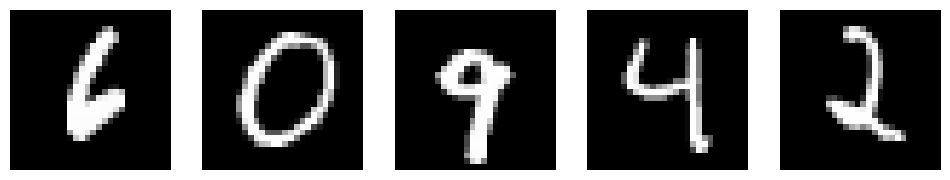

In [15]:
# Visualisasi 5 gambar acak
import random
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(random.choice(digits).reshape(28,28), cmap='gray')
    plt.axis("off")
plt.show()

Kita akan menggunakan **GridSearchCV** untuk mencari kombinasi parameter terbaik secara otomatis.

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Normalisasi data
digits /= 255.0
split_ind = int(len(digits)*0.7)
X_train, X_test, y_train, y_test = digits[:split_ind], digits[split_ind:], labels[:split_ind], labels[split_ind:]

parameters = {
    'hidden_layer_sizes': [50, 100], 
    'alpha': [0.001, 0.01], 
    'max_iter': [200]
}

model = MLPClassifier()
# Kita gunakan subset data agar proses training lebih cepat di lab ini
clf = GridSearchCV(estimator=model, param_grid=parameters, cv=3, n_jobs=-1)
clf.fit(X_train[:1500], y_train[:1500]) 

print("Parameter terbaik ditemukan:")
print(clf.best_params_)
bestmodel = clf.best_estimator_

Parameter terbaik ditemukan:
{'alpha': 0.01, 'hidden_layer_sizes': 100, 'max_iter': 200}


### **Evaluasi Model**
Mari kita lihat tingkat akurasi model pada data uji yang belum pernah dilihat sebelumnya.


In [17]:
from sklearn.metrics import accuracy_score
y_pred = bestmodel.predict(X_test)
print(f"Akurasi model terbaik: {accuracy_score(y_test, y_pred):.4f}")

Akurasi model terbaik: 0.9048


### **Kesimpulan**
Melalui lab ini, kita telah mempelajari evolusi jaringan saraf tiruan dari sekadar gerbang logika sederhana hingga menjadi mesin pengenal pola yang canggih dengan bantuan matematika matriks.


---
### Machine Learning Foundation (C) 2020 IBM Corporation
